# Visualizing Radial-Depth Interactions

This code will create some radial by depth profiles to help visualize interactions between depth and radius.

In [7]:
# Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Load Data

data_dir = "analyzed_data"
data_filename = "all_participants_combined.csv"
df = pd.read_csv(os.path.join(data_dir, data_filename))

/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_9381/2190137554.py:5: DtypeWarning: Columns (55,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(data_dir, data_filename))


## Analysis 1

### Data Quality Assurance

In [9]:
# Resolve column names
colmap = {}
colmap["SubjectID"] = "subject_id" if "subject_id" in df.columns else ("Subject ID" if "Subject ID" in df.columns else None)
colmap["scale_xy_dist"] = "scale_xy_dist" if "scale_xy_dist" in df.columns else None
colmap["no_vein"] = "no_vein" if "no_vein" in df.columns else None
colmap["sig"] = "sig" if "sig" in df.columns else None
colmap["in_tgt"] = "in_tgt" if "in_tgt" in df.columns else None
colmap["odss"] = "odss" if "odss" in df.columns else None
colmap["fgm"] = "fgm" if "fgm" in df.columns else None
colmap["d_norm"] = "d_norm" if "d_norm" in df.columns else None
colmap["d"] = "d" if "d" in df.columns else None
colmap["iso90"] = "iso90" if "iso90" in df.columns else None
colmap["iso0"] = "iso0" if "iso0" in df.columns else None
colmap["orth"] = "orth" if "orth" in df.columns else None
colmap["sur"] = "sur" if "sur" in df.columns else None
colmap["sur.1"] = "sur.1" if "sur.1" in df.columns else None
colmap["ctr"] = "ctr" if "ctr" in df.columns else None
colmap["iso-sur"] = "iso-sur" if "iso-sur" in df.columns else None
colmap["ctr-sur"] = "ctr-sur" if "ctr-sur" in df.columns else None

missing = [k for k,v in colmap.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create working frame with standardized names
work = df.rename(columns={v:k for k,v in colmap.items()})[list(colmap.keys())].copy()

# Coerce types
bool_cols = ["no_vein", "sig"]
for c in bool_cols:
    # cast truthy values to bool
    work[c] = work[c].astype(str).str.strip().str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    ).fillna(work[c].astype(bool))

# Ensure numeric
for c in ["scale_xy_dist", "odss", "fgm", "d_norm", "d"]:
    work[c] = pd.to_numeric(work[c], errors="coerce")


### Set Inclusion Criteria

* Visually responsive: task and loc pval < 0.01
* Nonveinous: passes within subject mean-normalized variance threshold

In [10]:
# Base mask: no_vein & sig
mask = work["no_vein"] & work["sig"]
work_masked = work.loc[mask].copy()

### Set Radial Thresholds

We're going to sweep through different radial thresholds to see how the profiles vary as we change radius.

In [11]:
def compute_profiles_for_threshold(df_thr: pd.DataFrame, value_cols, edges: np.ndarray, labels: np.ndarray) -> dict:
    """Compute depth profiles for given radial thresholded dataframe."""
    # Define depth bins
    eps = 1e-9
    edges_adj = edges.copy()
    edges_adj[-1] = edges_adj[-1] + eps
    binned = pd.cut(df_thr["d_norm"], bins=edges_adj, labels=labels, include_lowest=True)
    dat = df_thr.assign(depth_bin=binned).dropna(subset=["depth_bin"]).copy()
    dat["depth_bin"] = dat["depth_bin"].astype(int)

    # Subject × depth_bin means
    grp = dat.groupby(["SubjectID", "depth_bin"])[value_cols].mean()

    profiles = {}
    for m in value_cols:
        pivot = grp[m].unstack("SubjectID")
        prof = pivot.mean(axis=1, skipna=True)
        prof = prof.reindex(labels, fill_value=np.nan)
        profiles[m] = prof.values
    return profiles

Test profiles at scale_xy_dist=1.0:
  odss: [-0.5614931  -0.39881172  0.05322452  0.69073175 -0.44969034  0.82755712
  0.62523174]
  fgm: [0.73508431 0.27460646 0.41939697 0.68749614 1.31815131 1.4181923
 1.47807606]


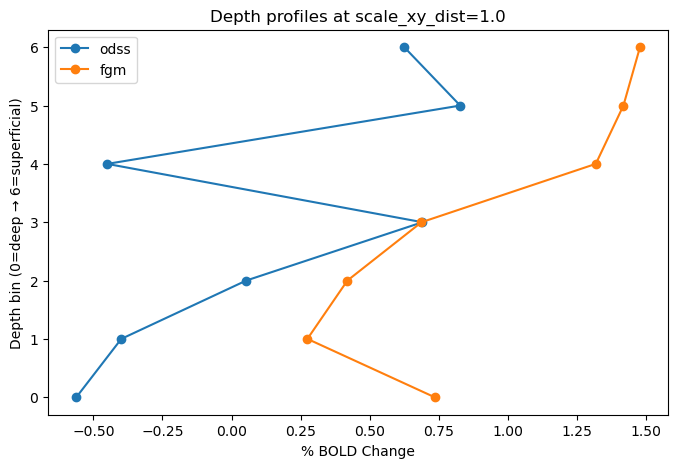

In [26]:
# Check profile at df_thr = 1
thr_test = 1.0
df_test = work_masked[work_masked["scale_xy_dist"] == thr_test]
value_cols = ["odss", "fgm"]
n_bins = 7
edges = np.linspace(0.0, 1.0, n_bins + 1)
labels = np.arange(n_bins)
profiles_test = compute_profiles_for_threshold(df_test, value_cols, edges, labels)
print(f"Test profiles at scale_xy_dist={thr_test}:")
for k,v in profiles_test.items():
    print(f"  {k}: {v}")

#plot profiles
plt.figure(figsize=(8,5))
for k,v in profiles_test.items():
    plt.plot(v, labels, marker='o', label=k)
plt.xlabel("% BOLD Change")
plt.ylabel("Depth bin (0=deep → 6=superficial)")
plt.title(f"Depth profiles at scale_xy_dist={thr_test}")
plt.legend()

In [14]:
# Unique thresholds from masked data
unique_r = np.sort(work_masked["scale_xy_dist"].dropna().unique())
if unique_r.size == 0:
    raise ValueError("No voxels remain after masking (no_vein & sig).")

# Depth bins
n_bins = 7
edges = np.linspace(0.0, 1.0, n_bins + 1)
labels = np.arange(n_bins)

metrics = ["odss", "fgm", "iso-sur", "ctr-sur", "iso0", "iso90", "orth", "sur", "ctr", "sur.1"]
profiles_stack = {m: [] for m in metrics}
thr_values = []

for thr in unique_r:
    df_thr = work_masked.loc[work_masked["scale_xy_dist"] <= thr]
    if df_thr.empty:
        continue
    profs = compute_profiles_for_threshold(df_thr, metrics, edges, labels)
    for m in metrics:
        profiles_stack[m].append(profs[m])
    thr_values.append(thr)

thr_values = np.array(thr_values)
matrices = {m: np.column_stack(profiles_stack[m]) for m in metrics}

# Save CSVs
out_dir = Path("analyzed_data/depth_profiles_by_radius")
if not out_dir.exists():
    out_dir.mkdir(parents=True, exist_ok=True)
for m, mat in matrices.items():
    cols = [f"{v:.6f}" for v in thr_values]
    pd.DataFrame(mat, index=[f"bin_{i}" for i in labels], columns=cols).to_csv(out_dir / f"depth_profiles_{m}.csv")

### Plot Results

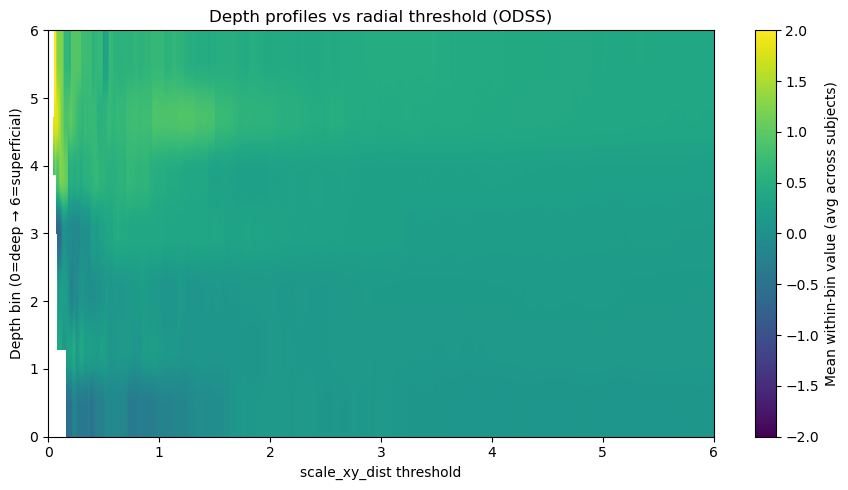

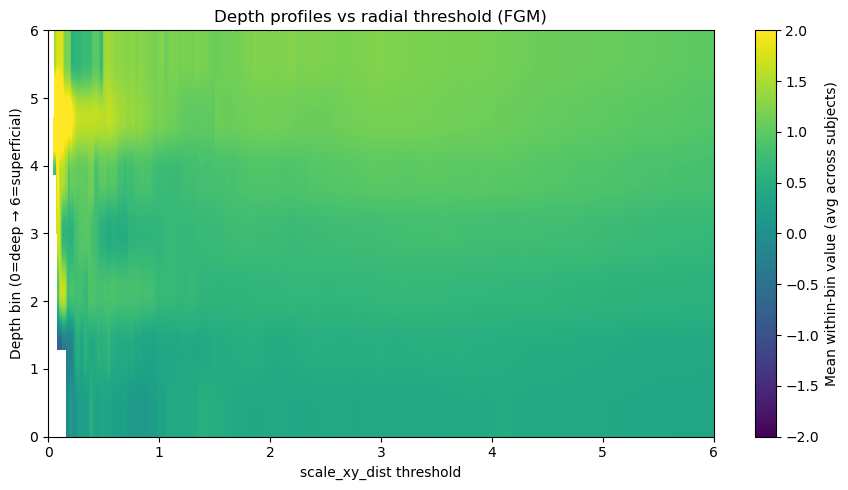

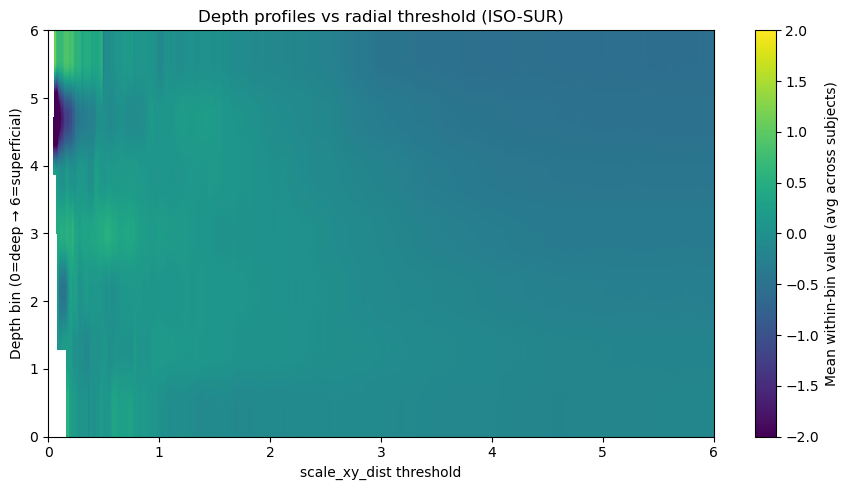

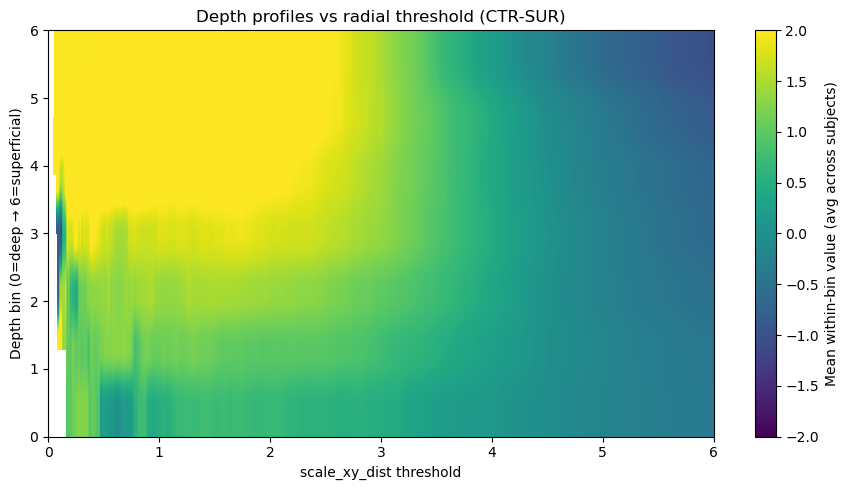

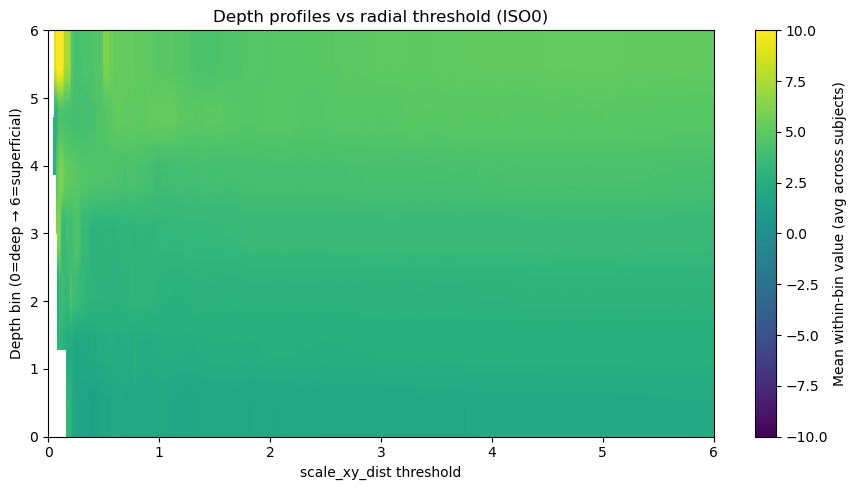

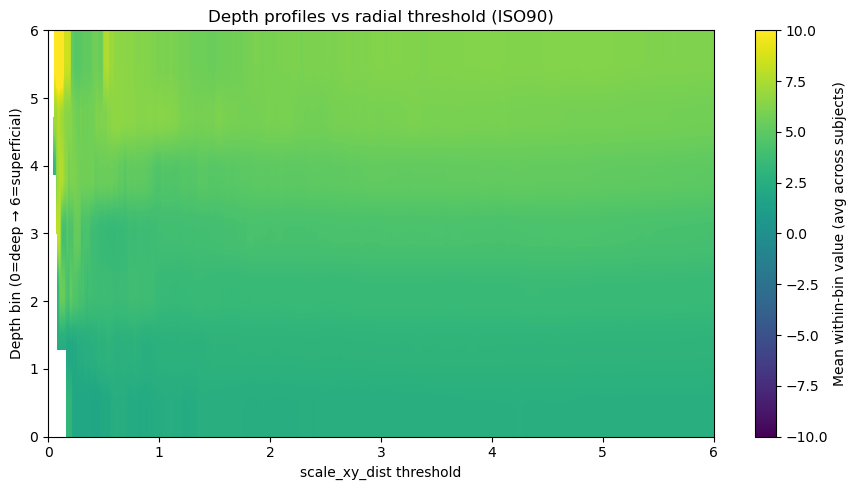

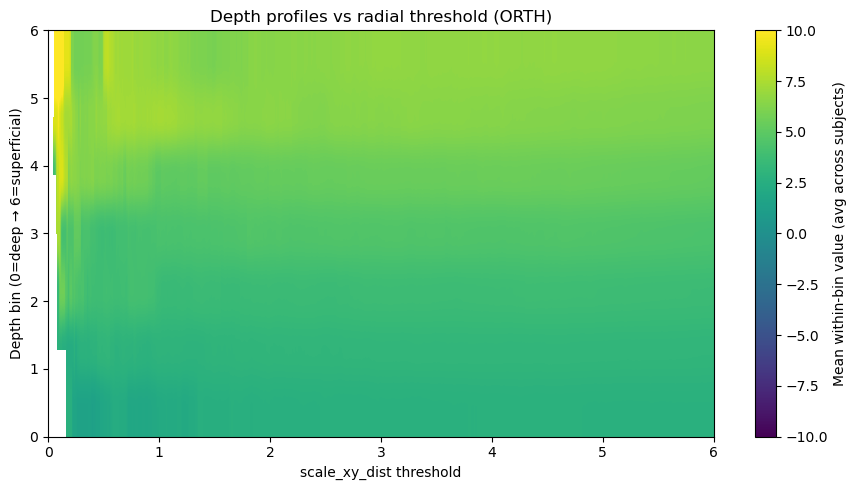

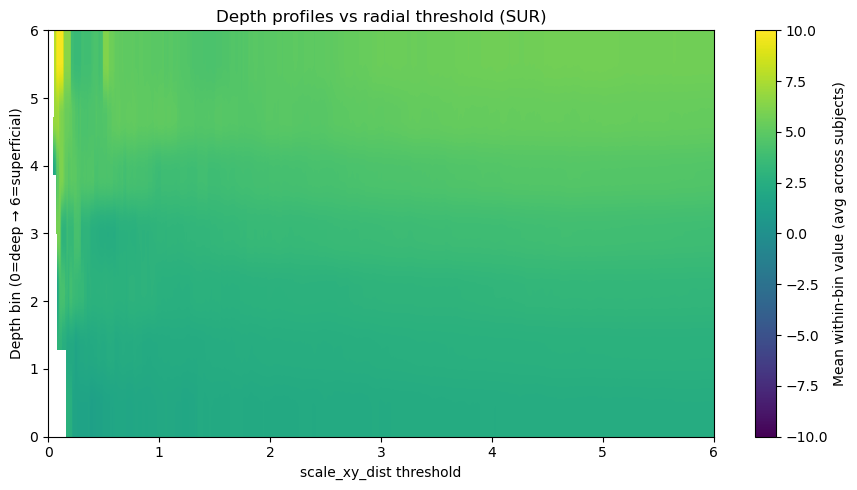

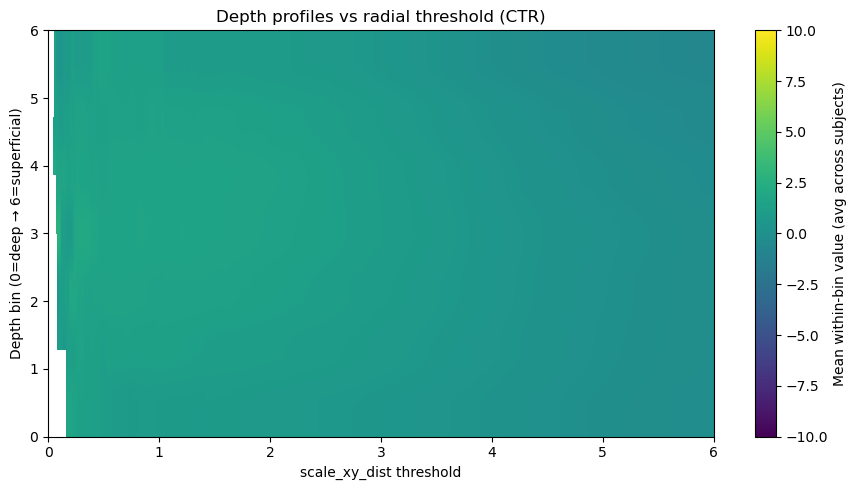

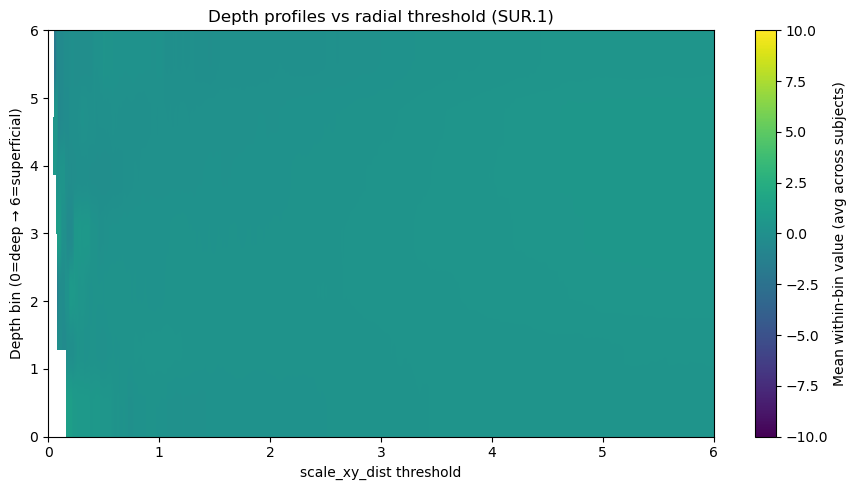

Outputs:
ODSS CSV: analyzed_data/depth_profiles_by_radius/depth_profiles_odss.csv
FGM CSV: analyzed_data/depth_profiles_by_radius/depth_profiles_fgm.csv
ODSS plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(odss).png
FGM plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(fgm).png
ISO-SUR plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(iso-sur).png
CTR-SUR plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(ctr-sur).png
ISO0 plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(iso0).png
ISO90 plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(iso90).png
ORTH plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(orth).png
SUR plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_radial_threshold_(sur).png
CTR plot: analyzed_data/depth_profiles_by_radius/depth_profiles_vs_ra

In [22]:
# Plotting
def plot_color_matrix(mat, thr_vals, title, xlims=None, vlims=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(mat, aspect="auto", origin="lower",
                   extent=[thr_vals.min(), thr_vals.max(), labels.min(), labels.max()])
    if xlims is not None:
        ax.set_xlim(xlims)
    if vlims is not None:
        im.set_clim(vlims)
    ax.set_xlabel("scale_xy_dist threshold")
    ax.set_ylabel("Depth bin (0=deep → 6=superficial)")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Mean within-bin value (avg across subjects)")
    fig.tight_layout()
    path = out_dir / (title.lower().replace(" ", "_") + ".png")
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path

odss_path = plot_color_matrix(matrices["odss"], thr_values, "Depth profiles vs radial threshold (ODSS)", xlims=[0,6], vlims=[-2,2])
fgm_path = plot_color_matrix(matrices["fgm"], thr_values, "Depth profiles vs radial threshold (FGM)", xlims=[0,6], vlims=[-2,2])
iso_sur_path = plot_color_matrix(matrices["iso-sur"], thr_values, "Depth profiles vs radial threshold (ISO-SUR)", xlims=[0,6], vlims=[-2,2])
ctr_sur_path = plot_color_matrix(matrices["ctr-sur"], thr_values, "Depth profiles vs radial threshold (CTR-SUR)", xlims=[0,6], vlims=[-2,2])
iso0_path = plot_color_matrix(matrices["iso0"], thr_values, "Depth profiles vs radial threshold (ISO0)", xlims=[0,6], vlims=[-10,10])
iso90_path = plot_color_matrix(matrices["iso90"], thr_values, "Depth profiles vs radial threshold (ISO90)", xlims=[0,6], vlims=[-10,10])
orth_path = plot_color_matrix(matrices["orth"], thr_values, "Depth profiles vs radial threshold (ORTH)", xlims=[0,6], vlims=[-10,10])
sur_path = plot_color_matrix(matrices["sur"], thr_values, "Depth profiles vs radial threshold (SUR)", xlims=[0,6], vlims=[-10,10])
ctr_path = plot_color_matrix(matrices["ctr"], thr_values, "Depth profiles vs radial threshold (CTR)", xlims=[0,6], vlims=[-10,10])
sur1_path = plot_color_matrix(matrices["sur.1"], thr_values, "Depth profiles vs radial threshold (SUR.1)", xlims=[0,6], vlims=[-10,10])

print("Outputs:")
print(f"ODSS CSV: {out_dir / 'depth_profiles_odss.csv'}")
print(f"FGM CSV: {out_dir / 'depth_profiles_fgm.csv'}")
print(f"ODSS plot: {odss_path}")
print(f"FGM plot: {fgm_path}")
print(f"ISO-SUR plot: {iso_sur_path}")
print(f"CTR-SUR plot: {ctr_sur_path}")
print(f"ISO0 plot: {iso0_path}")
print(f"ISO90 plot: {iso90_path}")
print(f"ORTH plot: {orth_path}")
print(f"SUR plot: {sur_path}")
print(f"CTR plot: {ctr_path}")
print(f"SUR.1 plot: {sur1_path}")

## Analysis 2

I nthe second analysis, I'll use a shifting window approach to plot profiles within an annular region of cortical space.